# Complete PyTorch Training Pipeline

## Binary Classification on Breast Cancer Dataset

A comprehensive guide covering the entire machine learning pipeline from data loading to model evaluation.

---

## Table of Contents

1. [Setup & Imports](#setup)
2. [Data Loading & Exploration](#data-loading)
3. [Data Preprocessing](#preprocessing)
4. [Model Architecture](#model)
5. [Training Loop](#training)
6. [Evaluation](#evaluation)
7. [Making Predictions](#predictions)
8. [Visualization](#visualization)

---

## 1. Setup & Imports

In [23]:
# Core libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
torch.cuda.empty_cache()
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.5.1+cu121
CUDA available: False
Using device: cpu


---

## 2. Data Loading & Exploration

In [24]:
# Load dataset
df = pd.read_csv('/home/saif/Desktop/pytorch/brest_cancer_detection.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset Overview:
Shape: (569, 33)

Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

First few rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [25]:
# Dataset information
print("Data Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df['diagnosis'].value_counts())
print(f"\nPercentage: \n{df['diagnosis'].value_counts(normalize=True) * 100}")

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se   

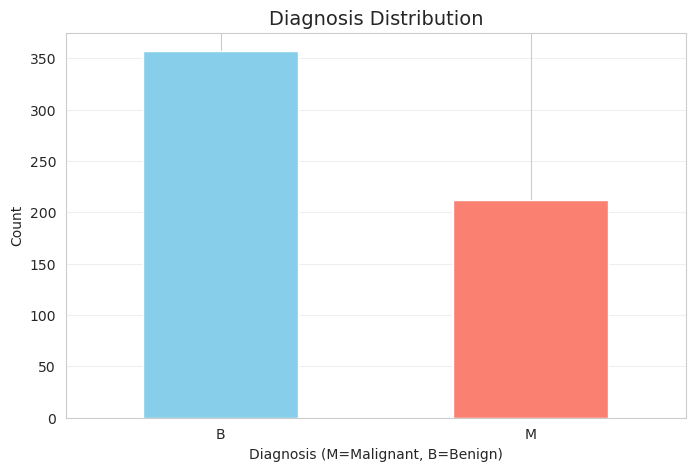

In [26]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
df['diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Diagnosis Distribution', fontsize=14)
plt.xlabel('Diagnosis (M=Malignant, B=Benign)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

---

## 3. Data Preprocessing

### 3.1 Data Cleaning

In [27]:
# Drop unnecessary columns
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Handle missing values if any
df = df.dropna()

print(f"After cleaning - Shape: {df.shape}")
df.head()

After cleaning - Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 3.2 Feature-Target Split

In [28]:
# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values.reshape(-1, 1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nSample features (first row):\n{X[0]}")
print(f"\nSample target: {y[0]}")

Features shape: (569, 30)
Target shape: (569, 1)

Sample features (first row):
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]

Sample target: ['M']


### 3.3 Train-Test Split

In [29]:
# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

print("Train-Test Split:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Train-Test Split:
X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455, 1)
y_test shape: (114, 1)


### 3.4 Feature Scaling

In [30]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test = scaler.transform(X_test)        # Only transform test (no fit!)

print("After scaling:")
print(f"Train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")
print(f"Test mean: {X_test.mean():.4f}, std: {X_test.std():.4f}")
print(f"\nSample scaled features (first row):\n{X_train[0]}")

After scaling:
Train mean: -0.0000, std: 1.0000
Test mean: -0.0240, std: 0.9311

Sample scaled features (first row):
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371 -0.6897715
 -0.68858645 -0.39817525 -1.0391547  -0.82505632 -0.10931776 -0.05597554
 -0.21009621 -0.01591326 -1.00518399 -0.91194199 -0.66281588 -0.65256108
 -0.70188911 -0.27539357  0.5797977   1.31324246  0.46690813  0.44598271
 -0.59615478 -0.63472223 -0.6102273  -0.23574392  0.05456632  0.02183673]


### 3.5 Label Encoding

In [31]:
# Encode labels: M (Malignant) -> 1, B (Benign) -> 0
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train.ravel())
y_test = label_encoder.transform(y_test.ravel())

print("Label Encoding:")
print(f"Classes: {label_encoder.classes_}")
print(f"B -> {label_encoder.transform(['B'])[0]}")
print(f"M -> {label_encoder.transform(['M'])[0]}")
print(f"\nEncoded y_train (first 10): {y_train[:10]}")

Label Encoding:
Classes: ['B' 'M']
B -> 0
M -> 1

Encoded y_train (first 10): [1 0 0 1 1 1 0 1 1 1]


### 3.6 Convert to PyTorch Tensors

In [32]:
# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)  # Shape: (n, 1)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print("PyTorch Tensors:")
print(f"X_train_tensor: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}, device: {X_train_tensor.device}")
print(f"X_test_tensor: {X_test_tensor.shape}, dtype: {X_test_tensor.dtype}, device: {X_test_tensor.device}")
print(f"y_train_tensor: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}, device: {y_train_tensor.device}")
print(f"y_test_tensor: {y_test_tensor.shape}, dtype: {y_test_tensor.dtype}, device: {y_test_tensor.device}")

PyTorch Tensors:
X_train_tensor: torch.Size([455, 30]), dtype: torch.float32, device: cpu
X_test_tensor: torch.Size([114, 30]), dtype: torch.float32, device: cpu
y_train_tensor: torch.Size([455, 1]), dtype: torch.float32, device: cpu
y_test_tensor: torch.Size([114, 1]), dtype: torch.float32, device: cpu


---

## 4. Model Architecture

### 4.1 Define Neural Network

In [ ]:
#class inherit from nn module
class BinaryClassifier(nn.Module):
    """
    Simple Binary Classification Neural Network
    
    Architecture:
    - Input Layer: 30 features
    - Hidden Layer 1: 64 neurons + ReLU
    - Hidden Layer 2: 32 neurons + ReLU
    - Output Layer: 1 neuron + Sigmoid
    """

    ## 30 --> 64 --> 32 --> 1
    def __init__(self, input_size): #input size means x_train
        #for inheritance
        super(BinaryClassifier, self).__init__()
        
        #input layer
        self.fc1 = nn.Linear(input_size, 64)
        #hidden layer
        self.fc2 = nn.Linear(64, 32)
        #output layer
        self.fc3 = nn.Linear(32, 1)
        
        #relu for hidden layers
        self.relu = nn.ReLU()
        #for output layers 
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Hidden layer 1
        x = self.fc1(x)
        x = self.relu(x)
        
        # Hidden layer 2
        x = self.fc2(x)
        x = self.relu(x)
        
        # Output layer
        x = self.fc3(x)
        x = self.sigmoid(x)
        
        return x

### 4.2 Initialize Model

In [53]:
# Get input size from data
input_size = X_train_tensor.shape[1]

# Create model
model = BinaryClassifier(input_size).to(device)

print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
BinaryClassifier(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Total parameters: 4,097
Trainable parameters: 4,097


### 4.3 Define Loss & Optimizer

In [50]:
# Loss function (Binary Cross Entropy)
criterion = nn.BCELoss()

# Optimizer (Adam)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training Configuration:")
print(f"\nLoss Function: {criterion}")
print(f"\nOptimizer: {optimizer}")

Training Configuration:

Loss Function: BCELoss()

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


---

## 5. Training Loop

In [36]:
# Training hyperparameters
num_epochs = 100
print_every = 10

# Track metrics
train_losses = []
train_accuracies = []

print(f"Training for {num_epochs} epochs...\n")
print("Epoch | Train Loss | Train Acc")
print("-" * 35)

for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    
    # Forward pass
    y_pred = model(X_train_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    
    # Backward pass
    optimizer.zero_grad()  # Clear gradients
    loss.backward()         # Compute gradients
    optimizer.step()        # Update weights
    
    # Calculate accuracy
    with torch.no_grad():
        predictions = (y_pred >= 0.5).float()
        accuracy = (predictions == y_train_tensor).float().mean()
    
    # Store metrics
    train_losses.append(loss.item())
    train_accuracies.append(accuracy.item())
    
    # Print progress
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {loss.item():10.6f} | {accuracy.item()*100:8.2f}%")

print("\nTraining completed!")

Training for 100 epochs...

Epoch | Train Loss | Train Acc
-----------------------------------
    1 |   0.682065 |    62.42%


   10 |   0.596955 |    78.90%
   20 |   0.490749 |    93.19%
   30 |   0.357088 |    94.51%
   40 |   0.233342 |    95.38%
   50 |   0.154012 |    95.82%
   60 |   0.111212 |    96.92%
   70 |   0.087768 |    98.68%
   80 |   0.074162 |    98.46%
   90 |   0.065306 |    98.46%
  100 |   0.058880 |    98.46%

Training completed!


---

## 6. Model Evaluation

### 6.1 Evaluate on Test Set

In [37]:
# Set model to evaluation mode
model.eval()

with torch.no_grad():
    # Get predictions
    y_pred_test = model(X_test_tensor)
    
    # Calculate test loss
    test_loss = criterion(y_pred_test, y_test_tensor)
    
    # Convert probabilities to class predictions
    y_pred_class = (y_pred_test >= 0.5).float()
    
    # Calculate test accuracy
    test_accuracy = (y_pred_class == y_test_tensor).float().mean()

print("Test Results:")
print(f"Test Loss: {test_loss.item():.6f}")
print(f"Test Accuracy: {test_accuracy.item()*100:.2f}%")

Test Results:
Test Loss: 0.062169
Test Accuracy: 99.12%


### 6.2 Detailed Metrics

In [38]:
# Convert to CPU and NumPy for sklearn metrics
y_true = y_test_tensor.cpu().numpy()
y_pred = y_pred_class.cpu().numpy()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        72
   Malignant       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114


Confusion Matrix:
[[72  0]
 [ 1 41]]


---

## 7. Making Predictions

In [39]:
# Make predictions on new data
def predict(model, features):
    """
    Make prediction on new features
    
    Args:
        model: trained model
        features: numpy array or tensor of features
    
    Returns:
        prediction (0 or 1), probability
    """
    model.eval()
    
    # Convert to tensor if needed
    if isinstance(features, np.ndarray):
        features = torch.FloatTensor(features).to(device)
    
    with torch.no_grad():
        probability = model(features)
        prediction = (probability >= 0.5).float()
    
    return prediction.item(), probability.item()

# Test on first sample
sample = X_test_tensor[0].unsqueeze(0)  # Add batch dimension
pred, prob = predict(model, sample)

print("Sample Prediction:")
print(f"Predicted class: {int(pred)} ({'Malignant' if pred == 1 else 'Benign'})")
print(f"Probability: {prob:.4f}")
print(f"Actual class: {int(y_test_tensor[0].item())} ({'Malignant' if y_test_tensor[0].item() == 1 else 'Benign'})")

Sample Prediction:
Predicted class: 0 (Benign)
Probability: 0.0010
Actual class: 0 (Benign)


---

## 8. Visualization

### 8.1 Training Loss Curve

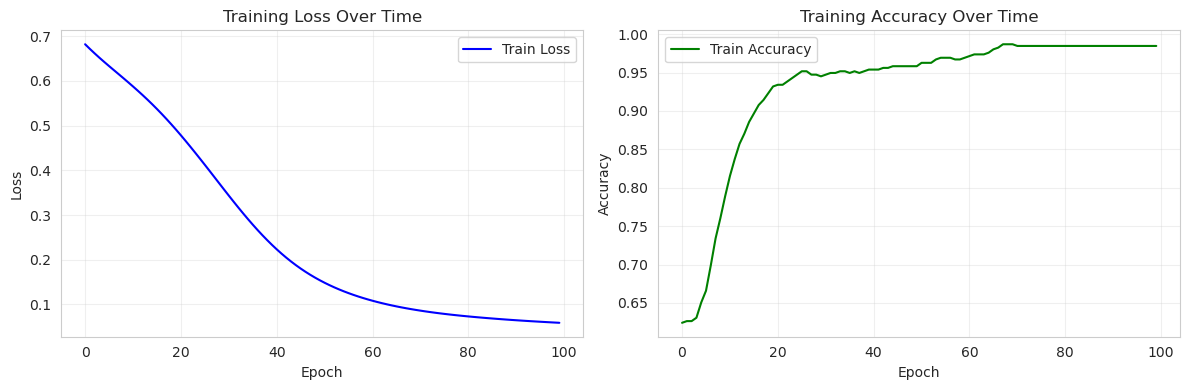

In [40]:
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Confusion Matrix Heatmap

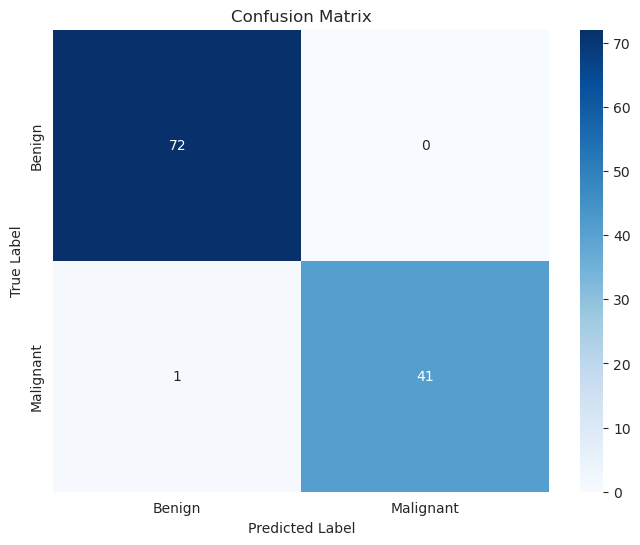

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

### 8.3 Prediction Distribution

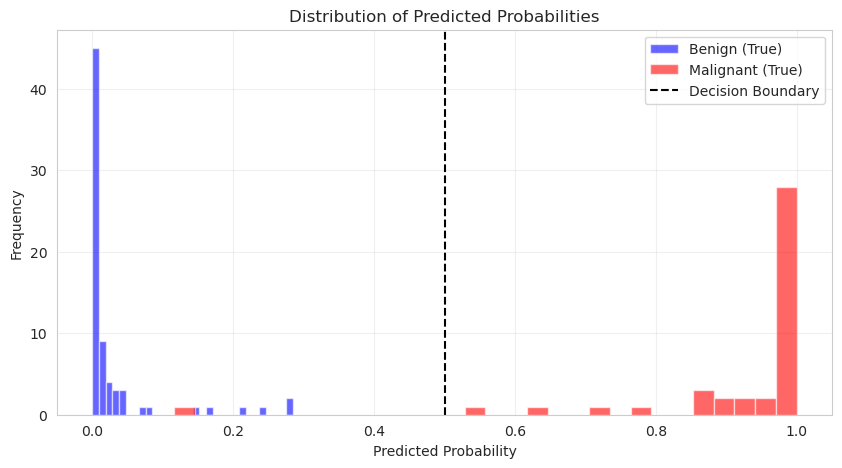

In [42]:
# Get all predictions
model.eval()
with torch.no_grad():
    all_probs = model(X_test_tensor).cpu().numpy()

plt.figure(figsize=(10, 5))

# Histogram of prediction probabilities
plt.hist(all_probs[y_test == 0], bins=30, alpha=0.6, label='Benign (True)', color='blue')
plt.hist(all_probs[y_test == 1], bins=30, alpha=0.6, label='Malignant (True)', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Boundary')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## 9. Save & Load Model

### 9.1 Save Model

In [43]:
# Save complete model
torch.save(model.state_dict(), 'breast_cancer_model.pth')
print("Model saved to 'breast_cancer_model.pth'")

# Save training info
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'test_accuracy': test_accuracy.item(),
    'input_size': input_size
}
torch.save(checkpoint, 'breast_cancer_checkpoint.pth')
print("Checkpoint saved to 'breast_cancer_checkpoint.pth'")

Model saved to 'breast_cancer_model.pth'
Checkpoint saved to 'breast_cancer_checkpoint.pth'


### 9.2 Load Model

In [44]:
# Load model
loaded_model = BinaryClassifier(input_size).to(device)
loaded_model.load_state_dict(torch.load('breast_cancer_model.pth'))
loaded_model.eval()

print("Model loaded successfully!")

# Verify it works
with torch.no_grad():
    test_pred = loaded_model(X_test_tensor[:5])
    print(f"\nSample predictions: {test_pred.squeeze().cpu().numpy()}")

Model loaded successfully!

Sample predictions: [9.7353128e-04 9.9997425e-01 7.1572833e-02 6.1693817e-01 2.8343871e-01]


/tmp/ipykernel_43539/3823272606.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('breast_cancer_model.pth'))
